**Extract ZIP Files**

In [ ]:
import os
import zipfile

# Define paths to the uploaded ZIP files
train_zip_path = '/content/train.zip'
test_zip_path = '/content/test.zip'
validation_zip_path = '/content/validation.zip'

# Define extraction directories
extracted_train_path = '/content/train'
extracted_test_path = '/content/test'
extracted_validation_path = '/content/validation'

# Function to extract zip files
def extract_zip(zip_path, extract_to):
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Extracted {zip_path} to {extract_to}")

# Extract all zip files
extract_zip(train_zip_path, extracted_train_path)
extract_zip(test_zip_path, extracted_test_path)
extract_zip(validation_zip_path, extracted_validation_path)

# Check the extracted directories
print("Contents of training directory:", os.listdir(extracted_train_path)[:5])
print("Contents of testing directory:", os.listdir(extracted_test_path)[:5])
print("Contents of validation directory:", os.listdir(extracted_validation_path)[:5])


Extracted /content/train.zip to /content/train
Extracted /content/test.zip to /content/test
Extracted /content/validation.zip to /content/validation
Contents of training directory: ['train']
Contents of testing directory: ['test']
Contents of validation directory: ['validation']


**Check Directory Contents**

In [ ]:
# Check subdirectories and contents for each folder
train_subdir = os.path.join(extracted_train_path, 'train')
test_subdir = os.path.join(extracted_test_path, 'test')
validation_subdir = os.path.join(extracted_validation_path, 'validation')

def check_directory_contents(path):
    contents = os.listdir(path)
    print(f"Directory: {path}")
    print(f"Total files: {len(contents)}")
    print(f"All files: {contents}")
    return contents

train_files = check_directory_contents(train_subdir)
test_files = check_directory_contents(test_subdir)
validation_files = check_directory_contents(validation_subdir)



Directory: /content/train/train
Total files: 6
All files: ['angry', 'fear', 'sad', 'surprise', 'happy', 'neutral']
Directory: /content/test/test
Total files: 6
All files: ['angry', 'fear', 'sad', 'surprise', 'happy', 'neutral']
Directory: /content/validation/validation
Total files: 6
All files: ['angry', 'fear', 'sad', 'surprise', 'happy', 'neutral']


**Validate Image Files**

In [ ]:
from PIL import Image

def validate_images(directory):
    """
    Validates that all files in the directory are readable images.
    Returns a list of valid and invalid files.
    """
    valid_images = []
    invalid_images = []

    for root, _, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    img.verify()  # Check if the image is valid
                valid_images.append(file_path)
            except Exception as e:
                invalid_images.append((file_path, str(e)))

    return valid_images, invalid_images

# Validate images in each directory
valid_train_images, invalid_train_images = validate_images(train_subdir)
valid_test_images, invalid_test_images = validate_images(test_subdir)
valid_validation_images, invalid_validation_images = validate_images(validation_subdir)

# Print summary
print(f"Training set: {len(valid_train_images)} valid images, {len(invalid_train_images)} invalid images.")
print(f"Testing set: {len(valid_test_images)} valid images, {len(invalid_test_images)} invalid images.")
print(f"Validation set: {len(valid_validation_images)} valid images, {len(invalid_validation_images)} invalid images.")

# If any invalid images, list the first few
if invalid_train_images:
    print("Sample invalid training images:", invalid_train_images[:5])
if invalid_test_images:
    print("Sample invalid testing images:", invalid_test_images[:5])
if invalid_validation_images:
    print("Sample invalid validation images:", invalid_validation_images[:5])


Training set: 4999 valid images, 0 invalid images.
Testing set: 750 valid images, 0 invalid images.
Validation set: 750 valid images, 0 invalid images.


**Load Image Data**

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations for data augmentation and normalization
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize images to a uniform size
    transforms.ToTensor(),       # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize pixel values to [-1, 1]
])

# Load datasets using ImageFolder
train_dataset = datasets.ImageFolder(root=train_subdir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_subdir, transform=transform)
validation_dataset = datasets.ImageFolder(root=validation_subdir, transform=transform)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

# Check dataset structure
print(f"Training dataset: {len(train_dataset)} images in {len(train_dataset.classes)} classes: {train_dataset.classes}")
print(f"Testing dataset: {len(test_dataset)} images in {len(test_dataset.classes)} classes: {test_dataset.classes}")
print(f"Validation dataset: {len(validation_dataset)} images in {len(validation_dataset.classes)} classes: {validation_dataset.classes}")


Training dataset: 4999 images in 6 classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Testing dataset: 750 images in 6 classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Validation dataset: 750 images in 6 classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']


**ResNet50 model**


Training Pre-trained Model (ResNet50)...
Epoch 1/30, Train Loss: 1.7087, Train Acc: 32.11%, Val Loss: 1.5161, Val Acc: 35.87%
Epoch 2/30, Train Loss: 1.4988, Train Acc: 41.77%, Val Loss: 1.5680, Val Acc: 43.87%
Epoch 3/30, Train Loss: 1.3917, Train Acc: 46.79%, Val Loss: 1.2916, Val Acc: 50.00%
Epoch 4/30, Train Loss: 1.3174, Train Acc: 50.19%, Val Loss: 1.3434, Val Acc: 48.40%
Epoch 5/30, Train Loss: 1.2324, Train Acc: 52.07%, Val Loss: 1.2243, Val Acc: 52.80%
Epoch 6/30, Train Loss: 1.1962, Train Acc: 55.29%, Val Loss: 1.3328, Val Acc: 48.67%
Epoch 7/30, Train Loss: 1.1513, Train Acc: 56.29%, Val Loss: 1.2849, Val Acc: 53.47%
Epoch 8/30, Train Loss: 1.1242, Train Acc: 57.85%, Val Loss: 1.2487, Val Acc: 52.00%
Epoch 9/30, Train Loss: 1.0977, Train Acc: 58.97%, Val Loss: 1.3200, Val Acc: 51.33%
Epoch 10/30, Train Loss: 0.9800, Train Acc: 63.05%, Val Loss: 1.2922, Val Acc: 56.67%
Epoch 11/30, Train Loss: 0.9056, Train Acc: 66.23%, Val Loss: 1.2481, Val Acc: 58.93%
Epoch 12/30, Train Lo

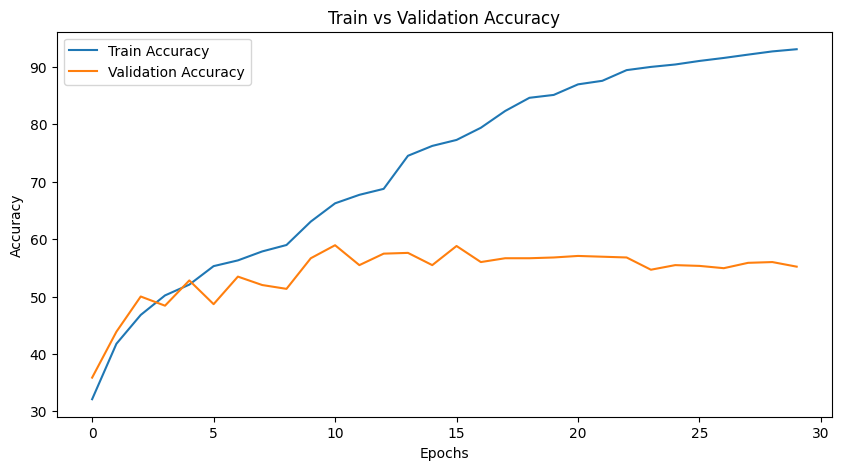

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

# Define device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training transformations
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Validation and test transformations
val_test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load datasets
train_dataset = ImageFolder("/content/train/train", transform=train_transforms)
validation_dataset = ImageFolder("/content/validation/validation", transform=val_test_transforms)
test_dataset = ImageFolder("/content/test/test", transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define class names
class_names = train_dataset.classes

# Load pre-trained ResNet50 model
print("\nTraining Pre-trained Model (ResNet50)...")
pretrained_model = models.resnet50(pretrained=True)

# Freeze all layers
for param in pretrained_model.parameters():
    param.requires_grad = False

# Allow fine-tuning of certain layers
for layer in [pretrained_model.layer4, pretrained_model.layer3, pretrained_model.layer2]:
    for param in layer.parameters():
        param.requires_grad = True

# Modify the final layer to fit the number of classes
num_classes = len(class_names)
pretrained_model.fc = nn.Linear(pretrained_model.fc.in_features, num_classes)

# Add a Dropout layer
pretrained_model.avgpool = nn.Sequential(
    pretrained_model.avgpool,
    nn.Dropout(p=0.7)
)

pretrained_model.to(device)

# Define loss function, optimizer, and scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, pretrained_model.parameters()),
    lr=0.0005,
    weight_decay=0.0001
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5, verbose=True)


# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    best_loss = float("inf")

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        val_loss, val_accuracy = evaluate_model(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")

        scheduler.step(val_loss)

    return train_losses, val_losses, train_accuracies, val_accuracies

# Evaluation function
def evaluate_model(model, dataloader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

# Display predictions function
def display_predictions(model, dataloader, class_names, num_images=10):
    model.eval()
    inputs, labels = next(iter(dataloader))
    inputs, labels = inputs[:num_images], labels[:num_images]
    inputs = inputs.to(device)
    with torch.no_grad():
        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)
    imshow(inputs.cpu(), labels, predictions.cpu(), class_names)

# Train the model
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    pretrained_model, train_loader, validation_loader, criterion, optimizer, scheduler, num_epochs=30
)

# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Train vs Validation Accuracy')
plt.show()


**Display Random Predictions**

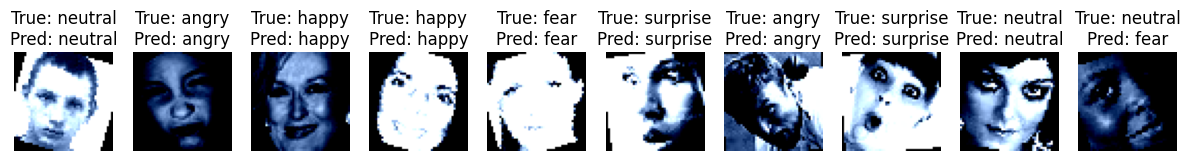

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

# Function to display images with true labels and predictions
def imshow(images, labels, predictions, class_names):
    # Convert images to displayable arrays
    images = images.numpy()
    if images.ndim == 4:
        images = np.transpose(images, (0, 2, 3, 1))  # Change shape if images are RGB

    # Ensure image values are between 0 and 1 (for float values) or 0 and 255 (for int values)
    images = np.clip(images, 0, 1)

    # Determine number of rows and columns for displaying images
    num_images = images.shape[0]
    fig, axes = plt.subplots(1, num_images, figsize=(15, 15))

    for i in range(num_images):
        ax = axes[i]
        ax.imshow(images[i])
        ax.set_title(f"True: {class_names[labels[i]]}\nPred: {class_names[predictions[i]]}")
        ax.axis('off')

    plt.show()

# Function to display random images from the dataset with predictions
def display_random_predictions(dataloader, model, class_names, num_images=10):
    model.eval()

    # Get random sample from the dataset
    dataset = dataloader.dataset
    indices = random.sample(range(len(dataset)), num_images)

    images, labels = zip(*[dataset[i] for i in indices])
    images = torch.stack(images)
    labels = torch.tensor(labels)

    # Send images to the device
    inputs = images.to(device)

    # Make predictions
    with torch.no_grad():
        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)

    # Display images with true labels and predictions
    imshow(images, labels, predictions.cpu(), class_names)

# Call the function to display random predictions from the training set
display_random_predictions(train_loader, pretrained_model, class_names, num_images=10)


**Calculate Model Accuracy**

In [ ]:
# Function to calculate model accuracy
def calculate_accuracy(model, train_loader, val_loader, test_loader, criterion):
    train_loss, train_accuracy = evaluate_model(model, train_loader, criterion)
    print(f"Train Accuracy: {train_accuracy:.2f}%")

    val_loss, val_accuracy = evaluate_model(model, val_loader, criterion)
    print(f"Validation Accuracy: {val_accuracy:.2f}%")

    test_loss, test_accuracy = evaluate_model(model, test_loader, criterion)
    print(f"Test Accuracy: {test_accuracy:.2f}%")

# Call the function to calculate and display accuracy for train, validation, and test sets
calculate_accuracy(pretrained_model, train_loader, validation_loader, test_loader, criterion)


Train Accuracy: 95.20%
Validation Accuracy: 55.20%
Test Accuracy: 55.20%


**Display Confusion Matrix**

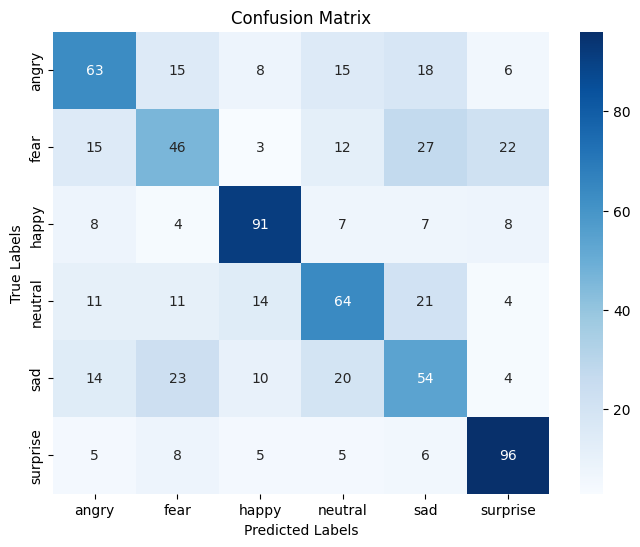

Accuracy: 0.55

Classification Report:
              precision    recall  f1-score   support

       angry       0.54      0.50      0.52       125
        fear       0.43      0.37      0.40       125
       happy       0.69      0.73      0.71       125
     neutral       0.52      0.51      0.52       125
         sad       0.41      0.43      0.42       125
    surprise       0.69      0.77      0.72       125

    accuracy                           0.55       750
   macro avg       0.55      0.55      0.55       750
weighted avg       0.55      0.55      0.55       750



In [ ]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Function to calculate and display confusion matrix and metrics
def plot_confusion_matrix_and_metrics(model, dataloader, classes, device):
    model.eval()  # Ensure model is in evaluation mode
    all_preds = []
    all_labels = []

    # Get predictions and true labels
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix using seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

    # Calculate classification metrics
    accuracy = accuracy_score(all_labels, all_preds)
    print(f'Accuracy: {accuracy:.2f}')

    # Print classification report (includes precision, recall, F1-score)
    report = classification_report(all_labels, all_preds, target_names=classes)
    print("\nClassification Report:")
    print(report)

# Example usage
# Call the function to display the confusion matrix and metrics from the test set
plot_confusion_matrix_and_metrics(pretrained_model, test_loader, train_loader.dataset.classes, device)


**Image Classification with ResNet-50**

In [ ]:
torch.save(pretrained_model.state_dict(), 'model_weights.pth')


The image '/content/download (1).jpg' belongs to class: sad


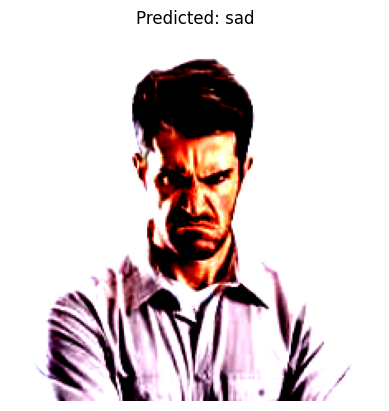

In [ ]:
# Function to predict multiple images
def predict_images(image_paths, model, transform, class_names, device):
    model.eval()  # Set the model to evaluation mode

    # Ensure image_paths is a list, even if a single image path is provided
    if isinstance(image_paths, str):
        image_paths = [image_paths]  # Convert to list if it's a single string

    # Loop over each image path
    for image_path in image_paths:
        # Check if the path is a valid file
        try:
            # Load the image
            image = Image.open(image_path)

            # Apply transformations
            image = transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device

            # Make the prediction
            with torch.no_grad():
                outputs = model(image)
                _, predicted = torch.max(outputs, 1)  # Get the class with the highest score

            # Get the predicted class
            predicted_class = class_names[predicted.item()]
            print(f"The image '{image_path}' belongs to class: {predicted_class}")

            # Display the image
            image = image.squeeze(0).cpu().numpy().transpose(1, 2, 0)  # Remove batch dimension and convert to numpy
            plt.imshow(image)
            plt.title(f"Predicted: {predicted_class}")
            plt.axis('off')
            plt.show()

        except Exception as e:
            print(f"Error loading image {image_path}: {e}")

# Provide the paths to the images you want to predict (single image or list of images)
image_paths = '/content/download (1).jpg'  # Single image path or list of paths

# Call the predict_images function
predict_images(image_paths, model, transform, class_names, device)
